# 02. Forced photometry on unWISE W1 and W2

The unWISE pixels are 2.75 arcsec across and the PSF is roughly 6 to 7 arcsec
wide, so several Euclid sources usually contribute to one WISE detection.
Forced photometry keeps the VIS positions and shapes fixed, convolves them
with the WISE PSF, and solves for all fluxes and a constant sky together.

The VIS models come from one call to the driver;
[notebook 01](01_multiband_forced_photometry.ipynb) explains how they are
built. The field is the same 200 arcsec region of EDF-N.

In [1]:
# Locate the package when running from either notebook directory.
import os, sys
from pathlib import Path
PROJECT_ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents)
                     if (p / "src/euclid_phot").is_dir()), None)
if PROJECT_ROOT is None:
    raise RuntimeError("Run this notebook from the repository.")
if "euclid_phot" in sys.modules:
    loaded_from = Path(sys.modules["euclid_phot"].__file__).resolve()
    if loaded_from != (PROJECT_ROOT / "src/euclid_phot/__init__.py").resolve():
        raise RuntimeError("Restart the kernel to load this repository's package.")
sys.path.insert(0, str(PROJECT_ROOT / "src"))
os.environ.setdefault("EUCLID_PHOT_DATA_DIR", str(PROJECT_ROOT / "examples/native_data"))

import time
import numpy as np
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord
from astropy.nddata import Cutout2D
import astropy.units as u

import euclid_phot as ep
from euclid_phot.wise import UNWISE_BAD_BITS

DATA_DIR = Path(os.environ["EUCLID_PHOT_DATA_DIR"])
TARGET_RA, TARGET_DEC = 269.48, 67.30
SIZE_ARCSEC = 200.0
WISE_BANDS = ("W1", "W2")
N_WORKERS = 10

## 1. VIS source models

With no Euclid target bands, `run_forced_photometry` fits only the prior
band: MER positions, the model-selection tree, the bright-star mask, and
the nearest GRID-PSF sample at each source. The fitted source list is
what the WISE fit needs.

In [2]:
t0 = time.time()
vis = ep.run_forced_photometry(
    TARGET_RA, TARGET_DEC, SIZE_ARCSEC,
    prior={"band": "VIS", "objects": "mer", "model_selection": "tree"},
    target_bands={"euclid": (), "wise": ()},
    psf_product="grid", persource_psf=True, mask_bright_stars=True,
    calibrate_errors=False, data_dir=DATA_DIR, n_workers=N_WORKERS,
)
sources = vis.sources
fit_quality = vis.flux_quality
print(f"\n{len(sources)} VIS sources in {time.time() - t0:.0f} s; "
      f"{int(fit_quality.sum())} pass the flux guard")

[1/7] MER catalog from cache (mer_catalog_269.4800_67.3000_200.fits)
[2/7] discover mosaics for VIS (lazy; only on a cache miss)
[3/7] fetch cutouts: VIS
[4/7] build per-band PSFs (GRID-PSF, radius=150")
[5/7] build Tractor image + source models on VIS
[5a] STARSIGNAL bright-star mask: 70222 pixels (1.76%) excluded from the VIS fit


[6/7] VIS fit (free, forced-photometry)



1116 VIS sources in 204 s; 1107 pass the flux guard


## 2. unWISE cutouts

The unWISE cutout extends 60 arcsec beyond the Euclid field on each side,
and the fit region is padded by five WISE FWHM, so that the light of
surrounding sources enters the model. Pixels flagged in the
unWISE bitmask as diffraction spikes, halos, or ghosts are dropped before
solving.

In [3]:
wise_box = max(180.0, SIZE_ARCSEC + 120.0)
wise = ep.fetch_unwise_cutouts(TARGET_RA, TARGET_DEC, wise_box,
                               data_dir=DATA_DIR / "wise")
print(f"unWISE box: {wise_box:.0f} arcsec, coadd_id={wise['coadd_id']}, "
      f"W1 shape {wise['W1']['data'].shape}")
mask = wise['W1'].get('mask')
if mask is not None:
    n_bad = int(((mask & UNWISE_BAD_BITS) != 0).sum())
    print(f"{n_bad} spike/halo/ghost pixels masked in the box")

unWISE box: 320 arcsec, coadd_id=2709p666, W1 shape (116, 116)
6 spike/halo/ghost pixels masked in the box


## 3. WISE forced photometry

Each VIS source is rendered with the unWISE PSF evaluated at the field
centre, and all fluxes are solved together with a constant sky. Sources of
the unWISE catalog (Schlafly et al. 2019) in the buffer around the field
are added so that their light is not absorbed by the Euclid sources.

The shared-morphology assumption is stronger here than in NISP. A galaxy
that is more compact or more extended in the infrared leaves a structured
residual, close neighbours can exchange flux even when the combined model
looks reasonable, and the reported errors omit that blend covariance.

In [4]:
wise_psfs = {band: ep.get_wise_psf(int(band[1]), wise['coadd_id'],
                                   ra=TARGET_RA, dec=TARGET_DEC)
             for band in WISE_BANDS}
t0 = time.time()
wise_results = ep.fit_wise_forced(
    sources, wise,
    ra=TARGET_RA, dec=TARGET_DEC, cutout_size_arcsec=SIZE_ARCSEC,
    bands=WISE_BANDS, psf_stamps=wise_psfs, prior_cutout=vis.cutouts['VIS'],
    catalog_cache_dir=DATA_DIR / "wise" / "catalogs",
)
print(f"WISE forced photometry done in {time.time() - t0:.1f} s")
for band in WISE_BANDS:
    r = wise_results[band]
    sn = r['flux_ujy'] / np.where(r['flux_err_ujy'] > 0, r['flux_err_ujy'], np.inf)
    print(f"  {band}: {r['n_supplement_sources']} buffer sources, "
          f"sky={r['sky']:+.3f} nMgy/pix, chi inflation={r['chi_inflation']:.2f}, "
          f"S/N>3 in {int(np.nansum(sn > 3))}/{len(sources)} sources")

WISE forced photometry done in 5.7 s
  W1: 300 buffer sources, sky=-1.398 nMgy/pix, chi inflation=1.91, S/N>3 in 554/1116 sources
  W2: 300 buffer sources, sky=-2.839 nMgy/pix, chi inflation=1.10, S/N>3 in 585/1116 sources


## 4. Data, model, and residuals

The full 200 arcsec field in W1 and W2. Data and model share one
brightness scale. The residual is data minus the complete model, sky
included, and the last column divides each pixel by its delivered error.

W1: formal sigma = 0.1753 Vega nMgy, chi std = 4.67 (k = 1.91), |chi|>3 = 18.30%
W2: formal sigma = 0.6261 Vega nMgy, chi std = 1.61 (k = 1.10), |chi|>3 = 4.65%


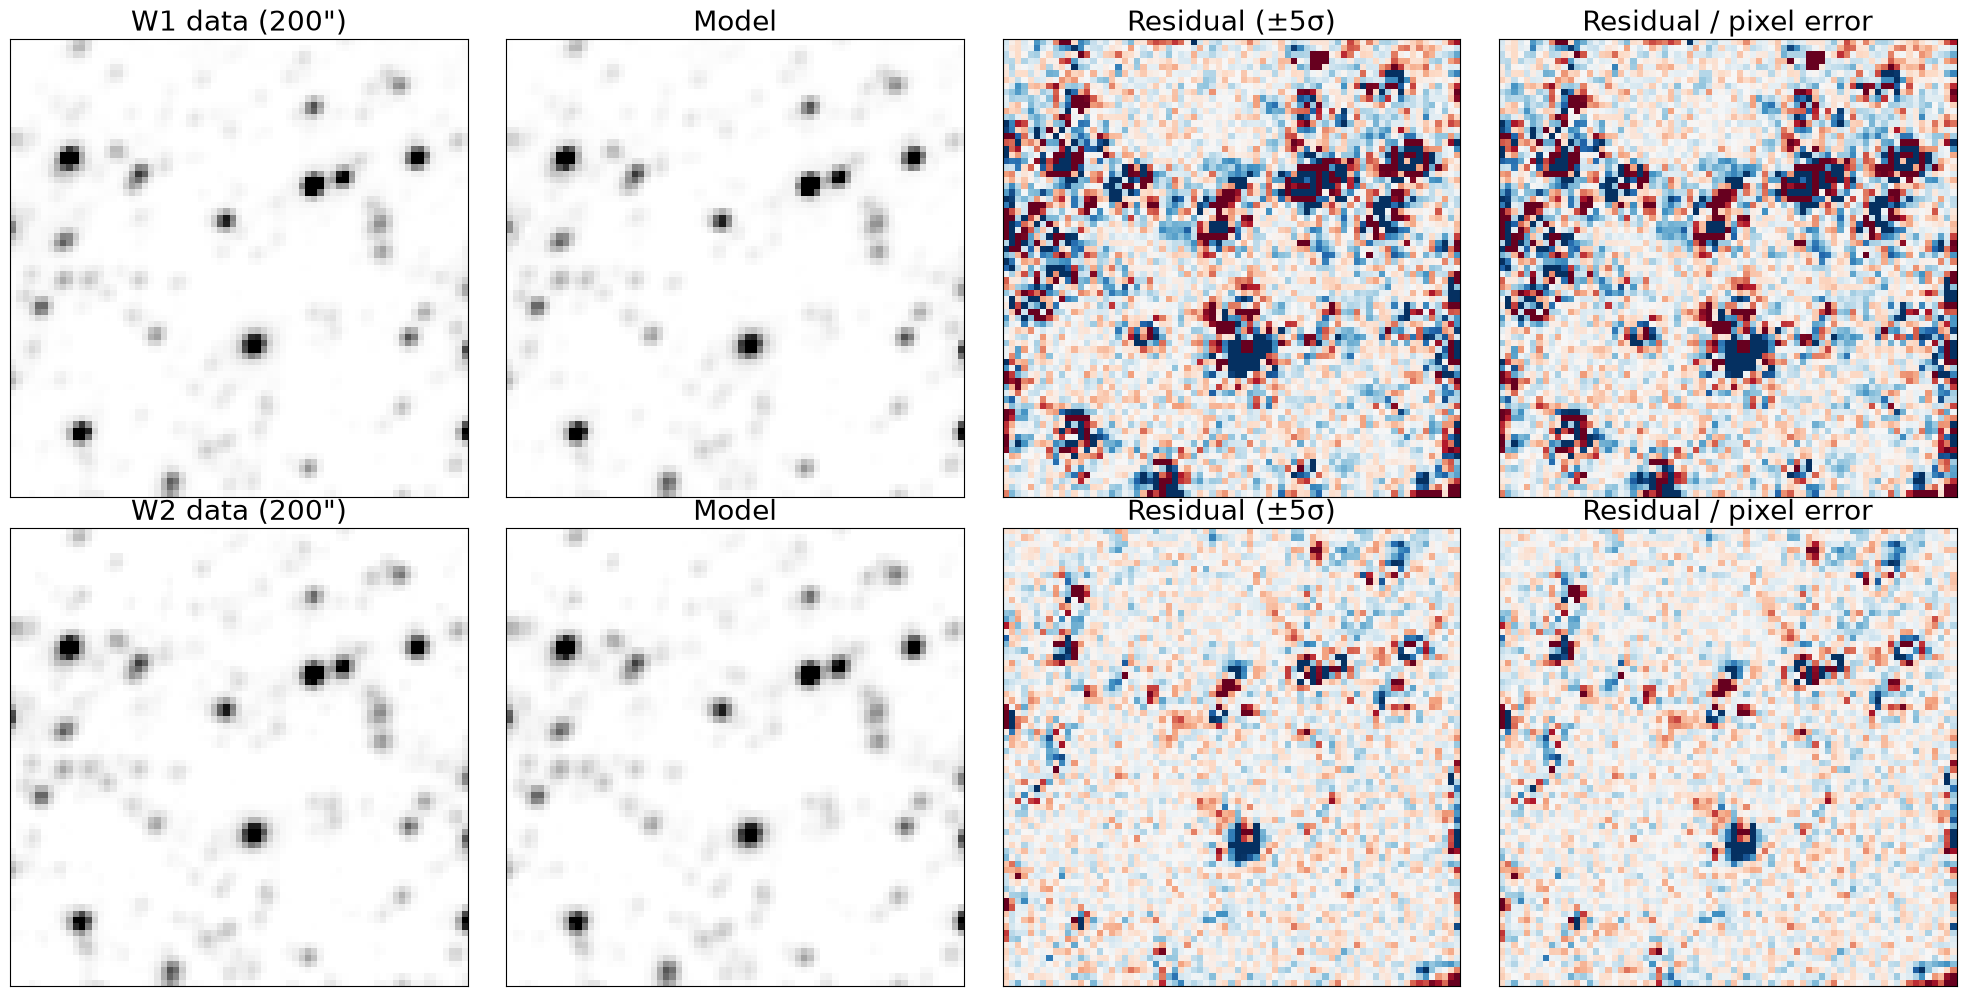

In [5]:
fig, axes = plt.subplots(len(WISE_BANDS), 4, figsize=(20, 5 * len(WISE_BANDS)))
for row, band in enumerate(WISE_BANDS):
    r = wise_results[band]
    cx, cy = r['wcs'].world_to_pixel_values(TARGET_RA, TARGET_DEC)
    box = SIZE_ARCSEC * u.arcsec
    crop = lambda img: Cutout2D(img, (float(cx), float(cy)), box, wcs=r['wcs'],
                                mode='partial', fill_value=0.0).data
    data, model, invvar = crop(r['data']), crop(r['model']), crop(r['invvar'])
    vmax = float(np.nanpercentile(data, 99.5))
    axes[row, 0].imshow(data, origin='lower', cmap='gray_r', vmin=0, vmax=vmax)
    axes[row, 0].set_title(f'{band} data ({SIZE_ARCSEC:.0f}")')
    axes[row, 1].imshow(model, origin='lower', cmap='gray_r', vmin=0, vmax=vmax)
    axes[row, 1].set_title('Model')
    _, info_res = ep.viz.show_residual(data, model, invvar=invvar,
                                       ax=axes[row, 2], title='Residual (±5σ)')
    _, info_chi = ep.viz.show_chi_map(data, model, invvar,
                                      ax=axes[row, 3], title='Residual / pixel error')
    for ax in axes[row]:
        ax.set_xticks([]); ax.set_yticks([])
        ax.title.set_fontsize(20)
    print(f"{band}: formal sigma = {info_res['formal_sigma']:.4f} Vega nMgy, "
          f"chi std = {info_chi['chi_std']:.2f} (k = {r['chi_inflation']:.2f}), "
          f"|chi|>3 = {info_chi['pct_chi_gt_3']:.2f}%")
plt.tight_layout(); plt.show()

### Inspect a WISE source

Change `WISE_SOURCE_INDEX` or `WISE_BAND` and rerun the next cell without
refitting. The index follows the Euclid source list. The default pair,
sources 65 and 41, is about 3 arcsec apart and shares one unWISE
detection. Crosses mark the two positions, with fitted fluxes labelled
below; the model includes all sources and the sky. The division of
blended light between such neighbours is sensitive to the source models.

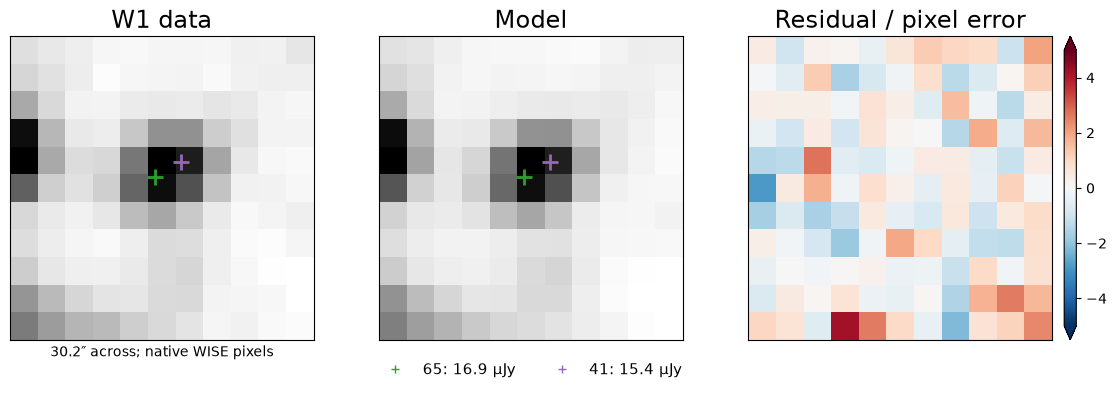

In [6]:
WISE_SOURCE_INDEX = 65
WISE_BAND = "W1"
WISE_SIZE_ARCSEC = 30.0

r = wise_results[WISE_BAND]
xy = np.array([r['wcs'].world_to_pixel_values(s.pos.ra, s.pos.dec) for s in sources])
centre = tuple(xy[WISE_SOURCE_INDEX])
cut = Cutout2D(r['data'], centre, WISE_SIZE_ARCSEC * u.arcsec, wcs=r['wcs'])
sy, sx = cut.slices_original
data, model = r['data'][sy, sx], r['model'][sy, sx]
weight = r['invvar'][sy, sx]
chi = np.where(weight > 0, (data - model) * np.sqrt(weight), np.nan)
extent = (sx.start - .5, sx.stop - .5, sy.start - .5, sy.stop - .5)
lo, hi = np.nanpercentile(data[weight > 0], [1, 99])

fig, axes = plt.subplots(1, 3, figsize=(13, 4.4))
for ax, im, title in zip(axes, (data, model, chi),
                         (f'{WISE_BAND} data', 'Model', 'Residual / pixel error')):
    residual_panel = ax is axes[2]
    shown = ax.imshow(im, origin='lower', extent=extent, interpolation='nearest',
                      cmap='RdBu_r' if residual_panel else 'gray_r',
                      vmin=-5 if residual_panel else lo, vmax=5 if residual_panel else hi)
    ax.set_title(title, fontsize=17); ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(shown, cax=axes[2].inset_axes([1.04, 0, .04, 1]), extend='both')

# The selected source and its brightest positive neighbour within one FWHM.
distance = np.hypot(*(xy - np.asarray(centre)).T) * 2.75
near = np.flatnonzero((distance < 6.94) & (r['flux_ujy'] > 0)
                      & (np.arange(len(sources)) != WISE_SOURCE_INDEX))
highlight = [WISE_SOURCE_INDEX] + ([near[np.argmax(r['flux_ujy'][near])]] if len(near) else [])
for j, colour in zip(highlight, ('tab:green', 'tab:purple')):
    for ax in axes[:2]:
        ax.plot(*xy[j], '+', color=colour, ms=12, mew=2)
    axes[1].plot([], [], '+', color=colour, label=f'{j}: {r["flux_ujy"][j]:.1f} µJy')
axes[1].legend(loc='upper center', bbox_to_anchor=(.5, -.03), ncol=2, fontsize=11, frameon=False)
axes[0].set_xlabel(f'{data.shape[1] * 2.75:.1f}″ across; native WISE pixels')
plt.subplots_adjust(wspace=.15, bottom=.19, right=.94); plt.show()

## 5. Cross-check against the Schlafly et al. (2019) unWISE catalog

[Schlafly et al. (2019, ApJS 240, 30), section 5.3](https://ui.adsabs.harvard.edu/abs/2019ApJS..240...30S)
normalize their PSF within 19×19 pixels. For this comparison our
full-stamp fluxes and errors are multiplied by the central 19×19 fraction
of the adopted PSF. This changes the amplitude convention only; the
exported fluxes keep the full-stamp convention.

The comparison uses unique positional matches with primary
detections and no unWISE flags. Sources with no Euclid neighbour brighter
than one third of their VIS flux within two WISE FWHM are highlighted.
Image depth, epochs, source lists, and deblending still differ between
the two measurements.

Schlafly detections: 333; unique matches: 121; VIS-isolated sources: 30
W1: PSF convention factor=0.95174; VIS-isolated S/N>5 n=23, median flux ratio=1.065; reported error ratio=0.41
W2: PSF convention factor=0.95880; VIS-isolated S/N>5 n=20, median flux ratio=1.028; reported error ratio=0.27


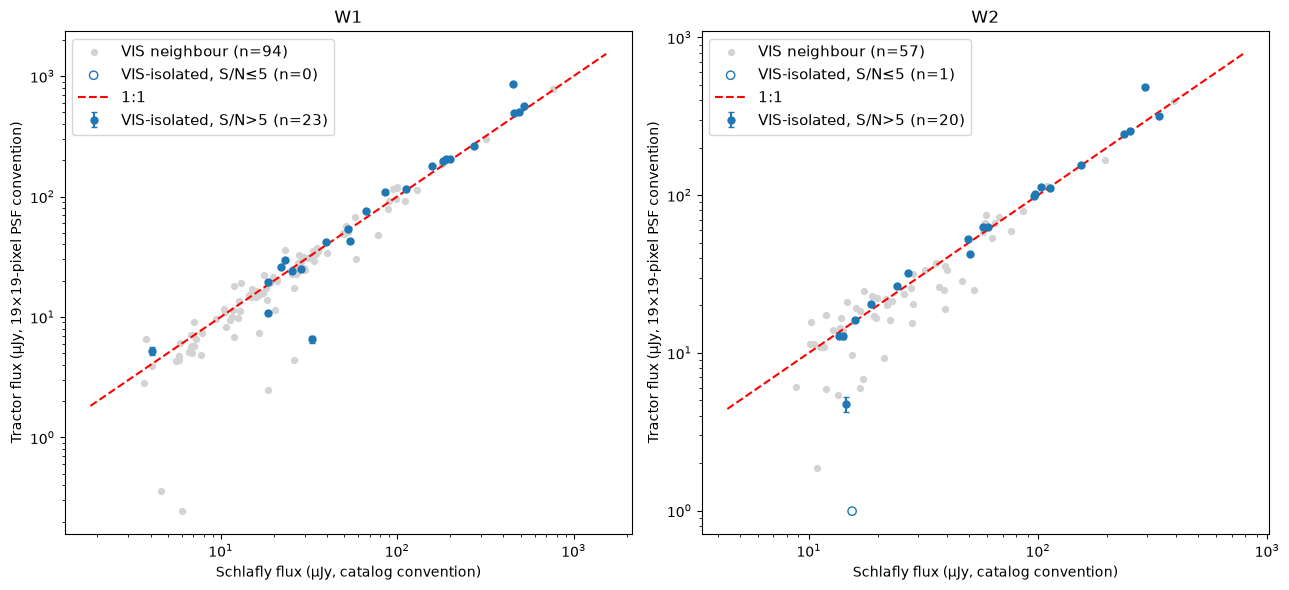

In [7]:
WISE_FWHM_ARCSEC = 6.94
MATCH_RADIUS_ARCSEC = 1.0

vis_cut = vis.cutouts['VIS']
h, w = vis_cut.shape
corner_ra, corner_dec = vis_cut.wcs.pixel_to_world_values([0, 0, w - 1, w - 1], [0, h - 1, 0, h - 1])
query_radius = (SkyCoord(corner_ra, corner_dec, unit='deg').separation(
    SkyCoord(TARGET_RA, TARGET_DEC, unit='deg')).arcsec.max() + MATCH_RADIUS_ARCSEC + 1.0)
uw_cat = ep.query_unwise_2019(TARGET_RA, TARGET_DEC, query_radius,
                              cache_dir=DATA_DIR / "wise" / "catalogs")

src_ra = np.array([s.getPosition().ra for s in sources])
src_dec = np.array([s.getPosition().dec for s in sources])
src_coord = SkyCoord(src_ra, src_dec, unit='deg')
idx, sep2d, _ = src_coord.match_to_catalog_sky(SkyCoord(uw_cat['ra'], uw_cat['dec'], unit='deg'))
matched = sep2d.arcsec < MATCH_RADIUS_ARCSEC
multiplicity = np.bincount(idx[matched], minlength=len(uw_cat))
unique_match = matched & (multiplicity[idx] == 1)
isolated = ep.select_isolated_sources(src_ra, src_dec, vis.fluxes_ujy['VIS'],
                                      radius_arcsec=2 * WISE_FWHM_ARCSEC, flux_fraction=1 / 3)
print(f"Schlafly detections: {len(uw_cat)}; unique matches: {unique_match.sum()}; "
      f"VIS-isolated sources: {isolated.sum()}")

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, band in zip(axes, WISE_BANDS):
    psf = wise_psfs[band]
    cy, cx = np.array(psf.shape) // 2
    factor = float(psf[cy - 9:cy + 10, cx - 9:cx + 10].sum() / psf.sum())
    trac = wise_results[band]['flux_ujy'] * factor
    err = wise_results[band]['flux_err_ujy'] * factor
    ref = np.asarray(uw_cat[band.lower() + '_ujy'], float)[idx]
    ref_err = np.asarray(uw_cat[band.lower() + '_err_ujy'], float)[idx]
    primary = np.asarray(np.ma.filled(uw_cat['primary_' + band[1]], 0))[idx] == 1
    unflagged = np.asarray(np.ma.filled(uw_cat['flags_unwise_' + band[1]], -1))[idx] == 0
    sn = np.divide(trac, err, out=np.zeros_like(trac), where=err > 0)
    selected = (unique_match & primary & unflagged & fit_quality
                & np.isfinite(trac) & (trac > 0) & np.isfinite(err) & (err > 0)
                & np.isfinite(ref) & (ref > 0) & np.isfinite(ref_err) & (ref_err > 0))
    hi = selected & isolated & (sn > 5)
    low = selected & isolated & ~hi
    crowded = selected & ~isolated
    ax.scatter(ref[crowded], trac[crowded], color='lightgray', s=18,
               label=f'VIS neighbour (n={crowded.sum()})')
    ax.scatter(ref[low], trac[low], facecolors='none', edgecolors='C0', s=36,
               label=f'VIS-isolated, S/N≤5 (n={low.sum()})')
    ax.errorbar(ref[hi], trac[hi], yerr=err[hi], fmt='o', color='C0', ms=5,
                capsize=2, label=f'VIS-isolated, S/N>5 (n={hi.sum()})')
    if selected.any():
        limits = [ref[selected].min() * 0.5, ref[selected].max() * 2]
        ax.plot(limits, limits, 'r--', label='1:1')
    ax.set(xscale='log', yscale='log', title=band,
           xlabel='Schlafly flux (µJy, catalog convention)',
           ylabel='Tractor flux (µJy, 19×19-pixel PSF convention)')
    ax.legend(fontsize=11)
    median = float(np.median(trac[hi] / ref[hi])) if hi.any() else np.nan
    error_ratio = float(np.median(err[hi] / ref_err[hi])) if hi.any() else np.nan
    print(f"{band}: PSF convention factor={factor:.5f}; VIS-isolated S/N>5 n={hi.sum()}, "
          f"median flux ratio={median:.3f}; reported error ratio={error_ratio:.2f}")
plt.tight_layout(); plt.show()

*The medians describe the VIS-isolated, S/N > 5 sample. The error ratio
compares the two reported error scales; it does not validate either.*

## 6. Catalog

The WISE fluxes are added to the VIS result and exported with `to_table`. The fluxes keep the full-stamp PSF
convention, which the table metadata records. The saved CSV keeps the rows
with a WISE measurement: identifier, position, model class, the `reliable`
flag, and flux and magnitude with their errors per band.

In [8]:
for band in WISE_BANDS:
    r = wise_results[band]
    vis.fluxes_ujy[band] = np.where(fit_quality, r['flux_ujy'], np.nan)
    vis.flux_errs_ujy[band] = np.where(fit_quality, r['flux_err_ujy'], np.nan)
vis.wise_results = wise_results

catalog = vis.to_table()
print(f"{len(catalog)} sources x {len(catalog.colnames)} columns")
print("WISE flux convention:", catalog.meta.get("wise_flux_convention"))

keep = ['object_id', 'ra', 'dec', 'model', 'reliable'] + [
    c for c in catalog.colnames
    if c.startswith(('flux_', 'mag_')) and not c.endswith(('_extcorr', '_quality'))]
measured = np.isfinite(np.asarray(catalog['flux_W1_ujy'], dtype=float))
catalog[keep][measured].write('wise_photometry.csv', overwrite=True)
print(f"wrote {int(measured.sum())} sources x {len(keep)} columns to wise_photometry.csv")

cols = ['object_id', 'ra', 'dec', 'model', 'flux_VIS_ujy',
        'flux_W1_ujy', 'flux_err_W1_ujy', 'mag_W1_ab', 'flux_W2_ujy', 'mag_W2_ab']
preview = catalog[np.isfinite(np.asarray(catalog['flux_W1_ujy']))].copy()
preview.sort('flux_W1_ujy')
preview[cols][-8:].pprint_all()

1116 sources x 33 columns
WISE flux convention: Fitted amplitudes with unit-sum finite PSF stamps, converted using the unWISE image zero point and adopted Vega-to-AB offsets. The central-19-pixel transfer is recorded for catalog comparison; it is not applied to these flux columns. Absolute PSF calibration and source-model mismatch are additional uncertainties.
wrote 1107 sources x 17 columns to wise_photometry.csv
     object_id              ra                dec           model        flux_VIS_ujy       flux_W1_ujy       flux_err_W1_ujy       mag_W1_ab         flux_W2_ujy         mag_W2_ab     
                           deg                deg                            uJy                uJy                 uJy                mag                uJy                mag        
------------------- ------------------ ----------------- ------------ ------------------ ------------------ ------------------- ------------------ ------------------ ------------------
2694406240673214685  269.44